In [9]:
#Ajout mode et visualisation

import os
from pathlib import Path
from collections import Counter
from PIL import Image
import pandas as pd
import numpy as np

# =====================================================
# CONFIGURATION
# =====================================================

dataset_path = Path("../covid/COVID-19_Radiography_Dataset")

# =====================================================
# VARIABLES
# =====================================================

records = []
sizes = []
corrupted_files = []
class_counts = {}
mode_counts = Counter()

# =====================================================
# HELPERS (ANOMALIES VISUELLES)
# =====================================================

def mean_intensity(img):
    arr = np.array(img.convert("L"))
    return arr.mean()

def contrast(img):
    arr = np.array(img.convert("L"))
    return arr.std()

# =====================================================
# CLASSES
# =====================================================

classes = [d.name for d in dataset_path.iterdir() if d.is_dir()]
print(f"Classes détectées : {classes}\n")

# =====================================================
# PARCOURS DATASET
# =====================================================

for cls in classes:

    img_dir = dataset_path / cls / "images"

    if not img_dir.exists():
        continue

    class_counts[cls] = 0

    for img_path in img_dir.glob("*"):

        try:
            with Image.open(img_path) as img:

                width, height = img.size
                mode = img.mode

                # features visuelles
                intensity = mean_intensity(img)
                cont = contrast(img)

                sizes.append((width, height))
                mode_counts[mode] += 1

                records.append({
                    "class": cls,
                    "filename": img_path.name,
                    "width": width,
                    "height": height,
                    "mode": mode,
                    "mean_intensity": intensity,
                    "contrast": cont
                })

                class_counts[cls] += 1

        except Exception:
            corrupted_files.append(str(img_path))

# =====================================================
# DATAFRAME
# =====================================================

df = pd.DataFrame(records)

# =====================================================
# STATISTIQUES GLOBALES
# =====================================================

print("\n" + "=" * 50)
print("STATISTIQUES GENERALES")
print("=" * 50)

print(f"Nombre total d'images : {len(df)}")
print(f"Nombre de classes : {len(class_counts)}")

# =====================================================
# DISTRIBUTION DES CLASSES
# =====================================================

print("\nDistribution des classes :")

for cls, count in class_counts.items():
    pct = 100 * count / len(df)
    print(f"{cls:<15} : {count:>6} images ({pct:.2f} %)")

# =====================================================
# DIMENSIONS
# =====================================================

print("\nDimensions des images")

print(f"Largeur min  : {df['width'].min()}")
print(f"Largeur max  : {df['width'].max()}")
print(f"Largeur moy  : {df['width'].mean():.2f}")

print(f"Hauteur min  : {df['height'].min()}")
print(f"Hauteur max  : {df['height'].max()}")
print(f"Hauteur moy  : {df['height'].mean():.2f}")

# =====================================================
# MODES (CANAUX)
# =====================================================

print("\nDistribution des modes (canaux) :")
for mode, count in mode_counts.items():
    print(f"{mode:<10} : {count} images")

# =====================================================
# TOP DIMENSIONS
# =====================================================

print("\nTop 10 des dimensions les plus fréquentes")

size_counter = Counter(sizes)

for size, count in size_counter.most_common(10):
    print(f"{size} -> {count} images")

# =====================================================
# CORRUPTED FILES
# =====================================================

print("\nFichiers corrompus")

if corrupted_files:
    print(f"{len(corrupted_files)} fichiers problématiques")
else:
    print("Aucun fichier corrompu détecté")

# =====================================================
# STATISTIQUES PAR CLASSE
# =====================================================

print("\n" + "=" * 50)
print("STATISTIQUES PAR CLASSE")
print("=" * 50)

class_stats = (
    df.groupby("class")
      .agg(
          nb_images=("filename", "count"),
          largeur_moy=("width", "mean"),
          hauteur_moy=("height", "mean")
      )
)

print(class_stats)

# =====================================================
# SAUVEGARDE
# =====================================================

df.to_csv("dataset_summary_mode_intensity_contrast.csv", index=False)

print("\nRésumé sauvegardé dans dataset_summary_mode_intensity_contrast.csv")

Classes détectées : ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']


STATISTIQUES GENERALES
Nombre total d'images : 21165
Nombre de classes : 4

Distribution des classes :
COVID           :   3616 images (17.08 %)
Lung_Opacity    :   6012 images (28.41 %)
Normal          :  10192 images (48.15 %)
Viral Pneumonia :   1345 images (6.35 %)

Dimensions des images
Largeur min  : 299
Largeur max  : 299
Largeur moy  : 299.00
Hauteur min  : 299
Hauteur max  : 299
Hauteur moy  : 299.00

Distribution des modes (canaux) :
L          : 21025 images
RGB        : 140 images

Top 10 des dimensions les plus fréquentes
(299, 299) -> 21165 images

Fichiers corrompus
Aucun fichier corrompu détecté

STATISTIQUES PAR CLASSE
                 nb_images  largeur_moy  hauteur_moy
class                                               
COVID                 3616        299.0        299.0
Lung_Opacity          6012        299.0        299.0
Normal               10192        299.0        299.0
Viral Pneumoni

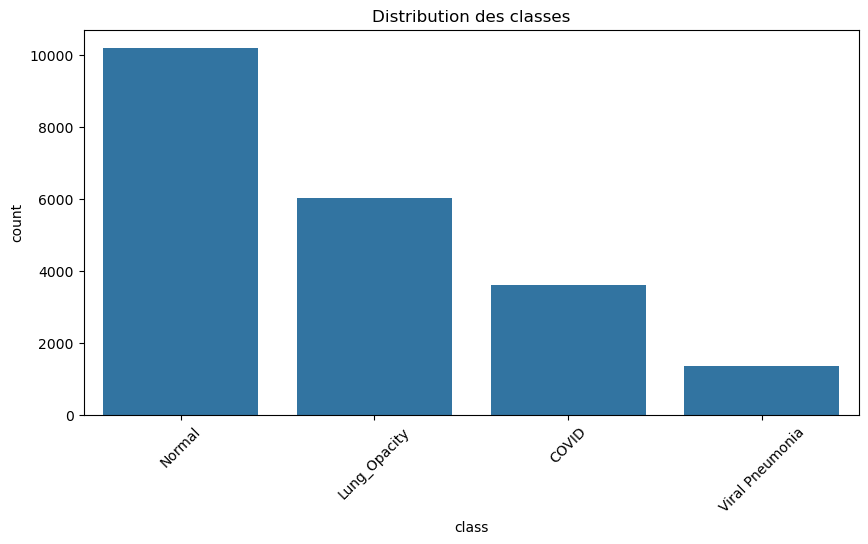

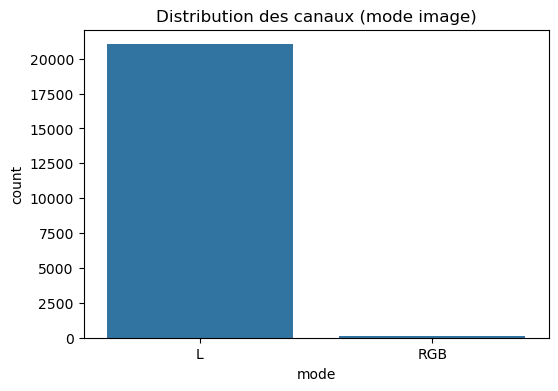

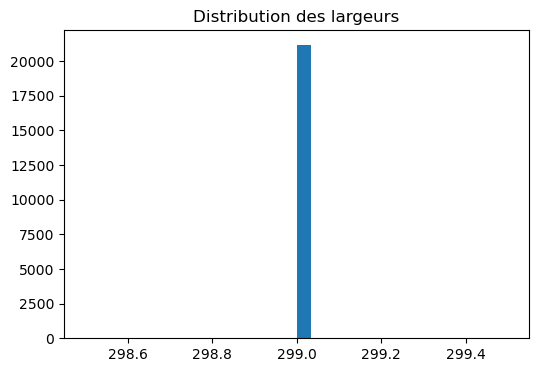

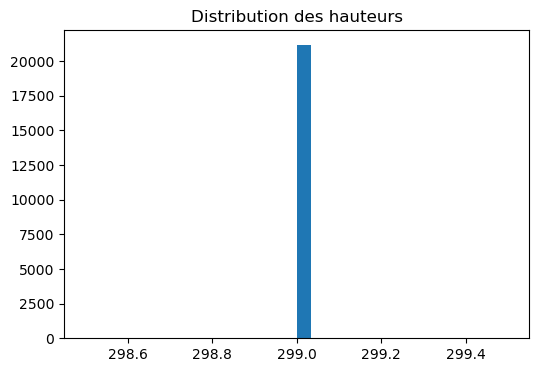

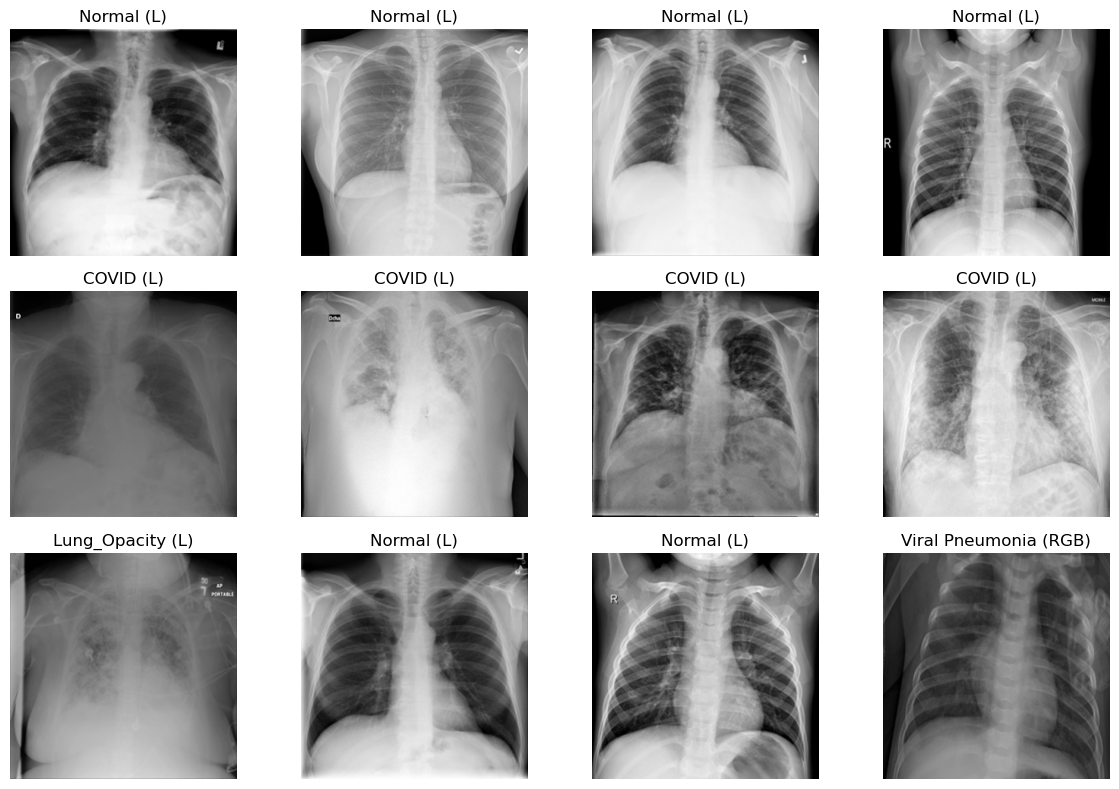

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import random

# =====================================================
# 1. DISTRIBUTION DES CLASSES
# =====================================================

plt.figure(figsize=(10,5))
sns.countplot(data=df, x="class", order=df["class"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Distribution des classes")
plt.show()

# =====================================================
# 2. DISTRIBUTION DES MODES (CANAUX)
# =====================================================

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="mode")
plt.title("Distribution des canaux (mode image)")
plt.show()

# =====================================================
# 3. DISTRIBUTION DES TAILLES
# =====================================================

plt.figure(figsize=(6,4))
plt.hist(df["width"], bins=30)
plt.title("Distribution des largeurs")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df["height"], bins=30)
plt.title("Distribution des hauteurs")
plt.show()

# =====================================================
# 4. EXEMPLES D'IMAGES PAR CLASSE
# =====================================================

fig, axes = plt.subplots(3, 4, figsize=(12, 8))

for ax in axes.flat:

    row = df.sample(1).iloc[0]
    img_path = dataset_path / row["class"] / "images" / row["filename"]

    img = Image.open(img_path)

    ax.imshow(img, cmap="gray" if img.mode == "L" else None)
    ax.set_title(f"{row['class']} ({row['mode']})")
    ax.axis("off")

plt.tight_layout()
plt.show()

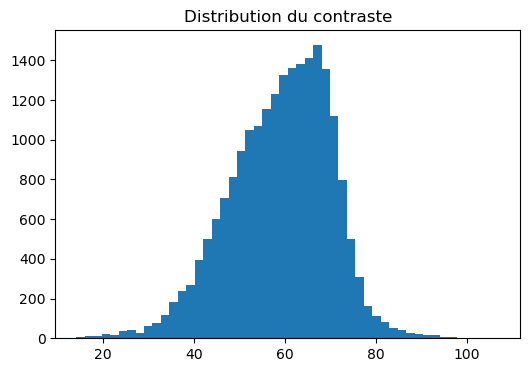

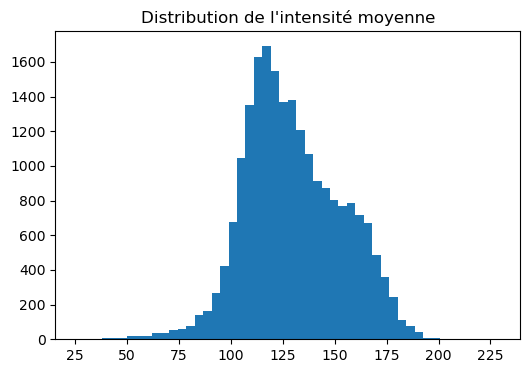


IMAGES EXTRÊMES - CONTRASTE FAIBLE


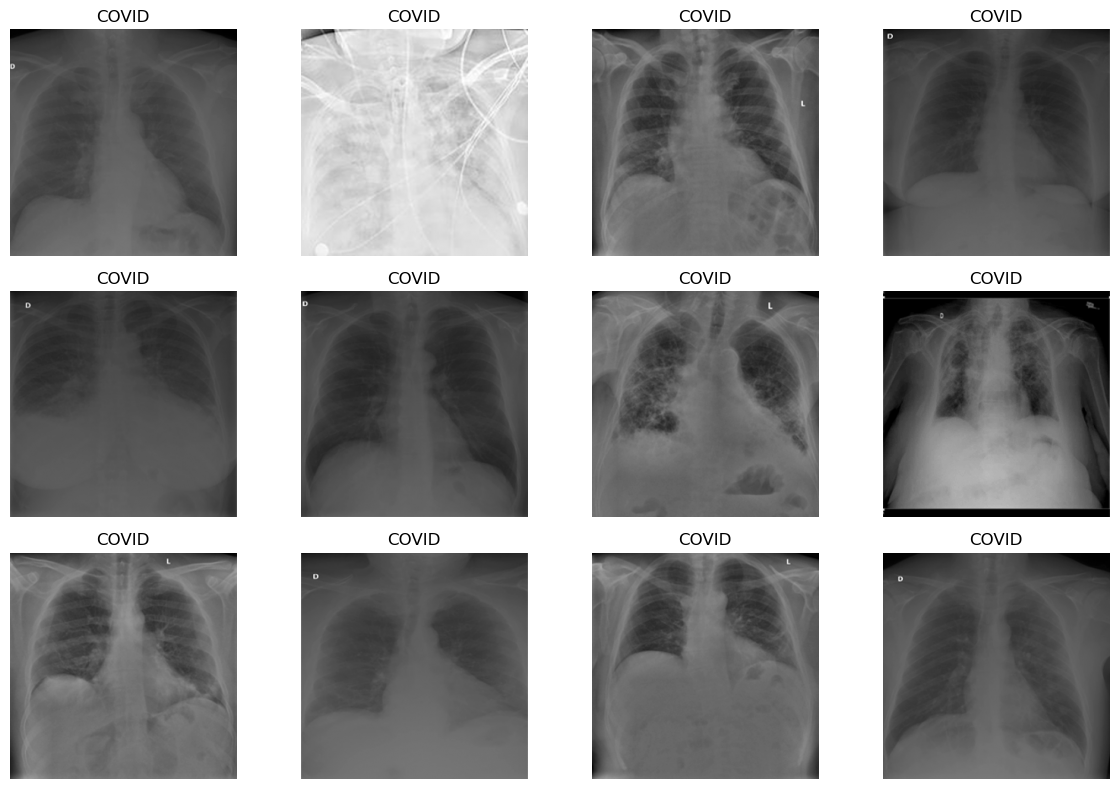

IMAGES EXTRÊMES (INTENSITÉ FAIBLE / SOMBRE)


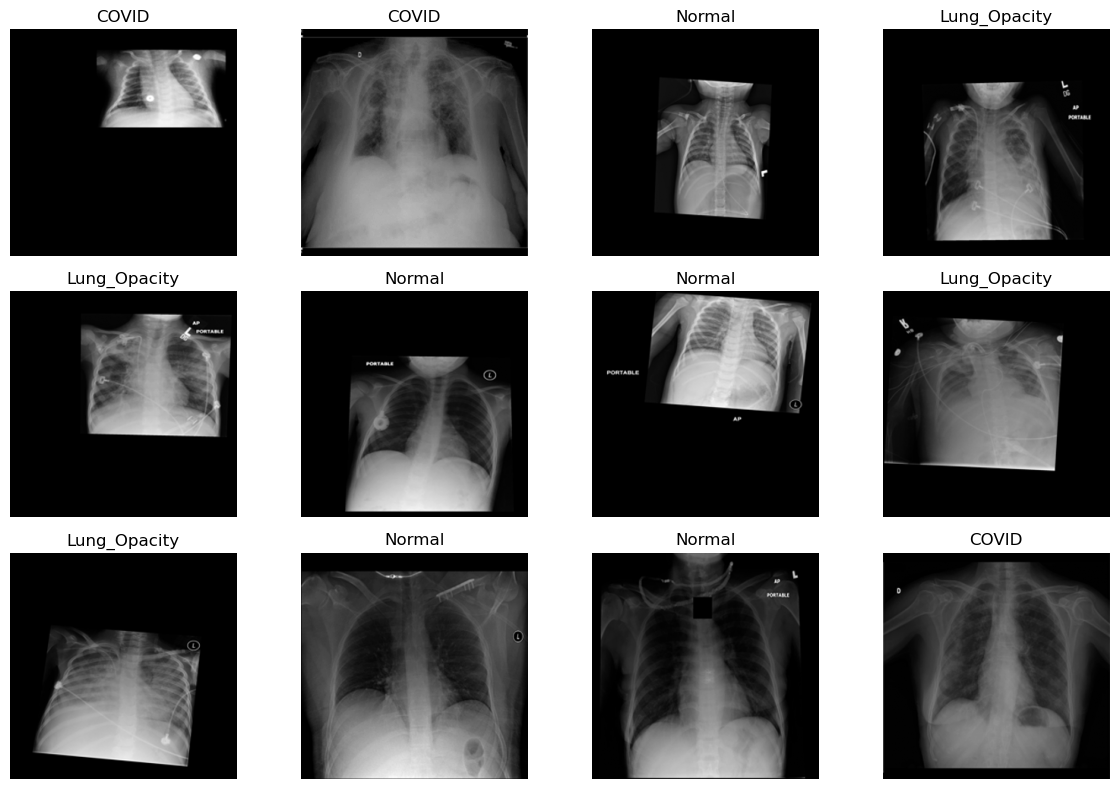

'\n#partie peut-être pas pertinente: TODO : vérifier puis supprimer\nprint("IMAGES LES PLUS "NORMALES"") \n\nnormal = df.sort_values("contrast", ascending=False).head(12)\n\nfig, axes = plt.subplots(3,4, figsize=(12,8))\n\nfor ax, (_, row) in zip(axes.flat, normal.iterrows()):\n    img_path = dataset_path / row["class"] / "images" / row["filename"]\n    img = Image.open(img_path)\n\n    ax.imshow(img, cmap="gray")\n    ax.set_title(f"{row[\'class\']}")\n    ax.axis("off")\n\nplt.tight_layout()\nplt.show()\n'

In [11]:
#ajout visu intensité et contraste
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
"""
#classes et modes déjà faits ci-dessus. TODO : à vérifier et supprimer
# =====================================================
# 1. DISTRIBUTION CLASSES
# =====================================================

plt.figure(figsize=(10,5))
sns.countplot(data=df, x="class", order=df["class"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Distribution des classes")
plt.show()

# =====================================================
# 2. MODES (CANAUX)
# =====================================================

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="mode")
plt.title("Distribution des canaux")
plt.show()

"""

# =====================================================
# 3. HISTO CONTRASTE
# =====================================================

plt.figure(figsize=(6,4))
plt.hist(df["contrast"], bins=50)
plt.title("Distribution du contraste")
plt.show()

# =====================================================
# 4. HISTO INTENSITÉ
# =====================================================

plt.figure(figsize=(6,4))
plt.hist(df["mean_intensity"], bins=50)
plt.title("Distribution de l'intensité moyenne")
plt.show()

# =====================================================
# 5. IMAGES EXTRÊMES (CONTRASTE FAIBLE)
# =====================================================

print("\nIMAGES EXTRÊMES - CONTRASTE FAIBLE")

low_contrast = df.nsmallest(12, "contrast")

fig, axes = plt.subplots(3,4, figsize=(12,8))

for ax, (_, row) in zip(axes.flat, low_contrast.iterrows()):
    img_path = dataset_path / row["class"] / "images" / row["filename"]
    img = Image.open(img_path)

    ax.imshow(img, cmap="gray")
    ax.set_title(f"{row['class']}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# =====================================================
# 6. IMAGES EXTRÊMES (INTENSITÉ FAIBLE / SOMBRE)
# =====================================================

print("IMAGES EXTRÊMES (INTENSITÉ FAIBLE / SOMBRE)")

dark = df.nsmallest(12, "mean_intensity")

fig, axes = plt.subplots(3,4, figsize=(12,8))

for ax, (_, row) in zip(axes.flat, dark.iterrows()):
    img_path = dataset_path / row["class"] / "images" / row["filename"]
    img = Image.open(img_path)

    ax.imshow(img, cmap="gray")
    ax.set_title(f"{row['class']}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# =====================================================
# 7. IMAGES LES PLUS "NORMALES"
# =====================================================
"""
#partie peut-être pas pertinente: TODO : vérifier puis supprimer
print("IMAGES LES PLUS \"NORMALES\"") 

normal = df.sort_values("contrast", ascending=False).head(12)

fig, axes = plt.subplots(3,4, figsize=(12,8))

for ax, (_, row) in zip(axes.flat, normal.iterrows()):
    img_path = dataset_path / row["class"] / "images" / row["filename"]
    img = Image.open(img_path)

    ax.imshow(img, cmap="gray")
    ax.set_title(f"{row['class']}")
    ax.axis("off")

plt.tight_layout()
plt.show()
"""

mean_intensity              contrast           
                          mean        std       mean        std
class                                                          
COVID               139.521210  25.029784  54.647365  14.829089
Lung_Opacity        126.021596  23.570601  57.397085   9.807737
Normal              129.389800  22.448670  61.559355   9.551679
Viral Pneumonia     125.369630  18.980974  58.745215  10.778896

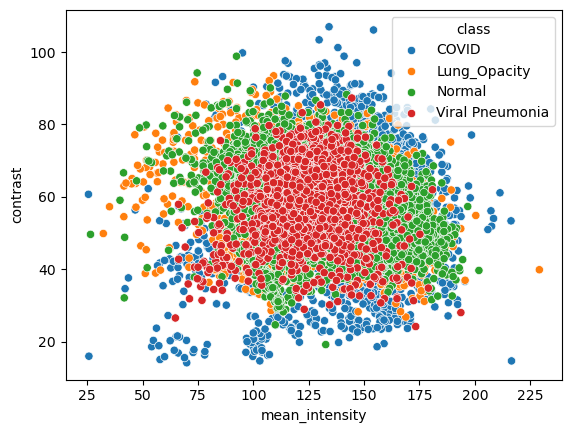

In [12]:
#scatterplot intensite vs contraste + valeurs by class
sns.scatterplot(
    data=df,
    x="mean_intensity",
    y="contrast",
    hue="class"
)

df.groupby("class")[["mean_intensity", "contrast"]].agg(
    ["mean", "std"]
)

In [14]:
#preprocessing : passage mode binaire
df["target"] = np.where(df["class"] == "COVID", 1, 0)

print(df["target"].value_counts())

print(df["target"].value_counts(normalize=True) * 100)


target_names = {
    0: "NON-COVID",
    1: "COVID"
}

print(
    df["target"]
    .map(target_names)
    .value_counts()
)

target
0    17549
1     3616
Name: count, dtype: int64
target
0    82.91519
1    17.08481
Name: proportion, dtype: float64
target
NON-COVID    17549
COVID         3616
Name: count, dtype: int64


In [16]:
#split train stratifie + verif proportion après split
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["target"],
    random_state=42
)

print("TRAIN")
print(
    train_df["target"]
    .value_counts(normalize=True) * 100
)

print("\nTEST")
print(
    test_df["target"]
    .value_counts(normalize=True) * 100
)

TRAIN
target
0    82.914009
1    17.085991
Name: proportion, dtype: float64

TEST
target
0    82.919915
1    17.080085
Name: proportion, dtype: float64
